# 파라미터 스윕 (Parameter Sweep)

이 노트북에서는 복합 양자 시스템의 파라미터 의존성을 분석합니다.

**다루는 내용:**
- 단일 큐비트 자속 스윕 (`SingleSystemSweep`)
- 복합 시스템의 dressed 스펙트럼 스윕 (`ParameterSweep`)
- Bare vs Dressed 전이 비교
- 상태 추적 (bare/dressed 매핑)
- Julia-style preslicing (`sweep[:]`) + transition plots
- scqubits-style bare/dispersive highlighting 과 adiabatic branch 해석의 차이
- 분산 시프트 $\chi$ vs 자속
- 다중 큐비트 시스템



In [1]:
using ScQubitsMimic
using CairoMakie

_scqubitsmimic_example_dir = normpath(joinpath(dirname(pathof(ScQubitsMimic)), "..", "examples"))
if !isdefined(Main, :ScQubitsMimicExampleMakie)
    include(joinpath(_scqubitsmimic_example_dir, "makie_fontsetup.jl"))
end
ScQubitsMimicExampleMakie.setup_makie_font!()


"Apple SD Gothic Neo"

## 1. 시스템 정의

자속 가변 Transmon 큐비트와 공진기로 구성된 circuit QED 시스템을 정의합니다.

$$H = H_{\text{qubit}}(\Phi_{\text{ext}}) + H_{\text{res}} + g \, \hat{n} \otimes (\hat{a} + \hat{a}^\dagger)$$

외부 자속 $\Phi_{\text{ext}}$를 스윕하면 큐비트 주파수가 변하면서 공진기와의 상호작용이 달라집니다.

In [2]:
tmon = TunableTransmon(EJmax=20.0, EC=0.3, d=0.1, flux=0.0, ng=0.0,
                       ncut=15, truncated_dim=4)
osc = Oscillator(E_osc=5.5, truncated_dim=6)

hs = HilbertSpace([tmon, osc])

# 결합: g * n̂_tmon ⊗ (a + a†)
g = 0.15
add_interaction!(hs, g, [tmon, osc],
    [s -> n_operator(s),
     s -> annihilation_operator(s) + creation_operator(s)])

println("시스템 구성:")
println("  TunableTransmon: EJmax=$(tmon.EJmax), EC=$(tmon.EC), d=$(tmon.d)")
println("  Oscillator: ω_r=$(osc.E_osc) GHz")
println("  결합: g=$g GHz")
println("  전체 힐베르트 공간: $(hilbertdim(hs))")

시스템 구성:
  TunableTransmon: EJmax=20.0, EC=0.3, d=0.1
  Oscillator: ω_r=5.5 GHz
  결합: g=0.15 GHz
  전체 힐베르트 공간: 186


## 2. 단일 큐비트 자속 스윕

먼저 bare 큐비트(공진기 결합 없이)의 에너지 스펙트럼을 자속 함수로 계산합니다.

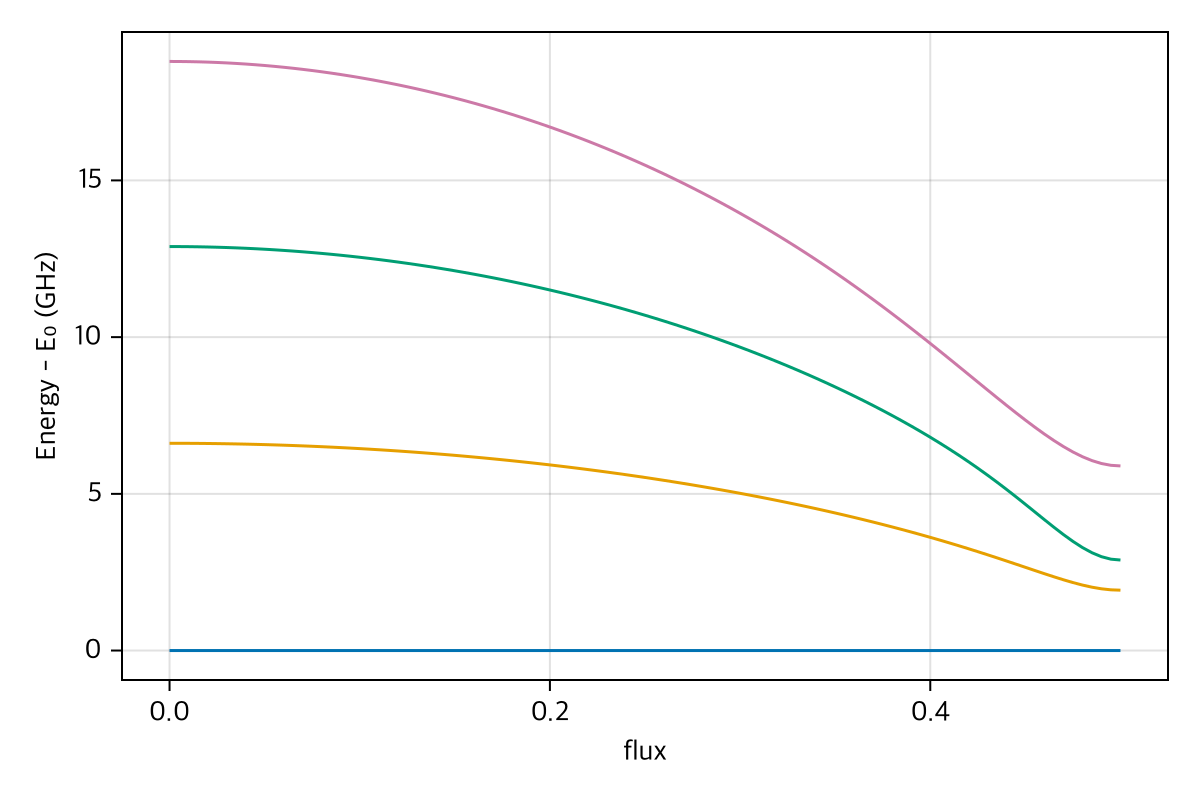

In [3]:
tmon.flux = 0.0
bare_sweep = SingleSystemSweep(tmon, :flux, range(0.0, 0.5, length=101); evals_count=4)
plot_evals_vs_paramvals(bare_sweep; subtract_ground=true, evals_count=4)

## 3. ParameterSweep Dressed 스펙트럼 스윕

`ParameterSweep`는 복합 시스템 전체의 dressed 에너지를 파라미터 함수로 계산합니다. 자속 변화에 따라 큐비트 주파수가 공진기 주파수에 접근하면 **avoided crossing** (반교차)이 나타납니다.

현재 Julia codebase는 scqubits naming parity를 위해 coupled-system sweep 이름을 `ParameterSweep`로 맞추고, bare single-system sweep는 `SingleSystemSweep`로 분리합니다.

`ParameterSweep`의 bare/dressed labeling은 sweep-local 설정입니다. 기본값은 strict (`ignore_low_overlap=false`)이며, `hs.ignore_low_overlap`를 자동 상속하지 않습니다. 따라서 lookup 기반 state tracking은 bare-state character를 추적하는 층이고, avoided crossing에서의 adiabatic branch continuity와는 구분해서 해석해야 합니다.



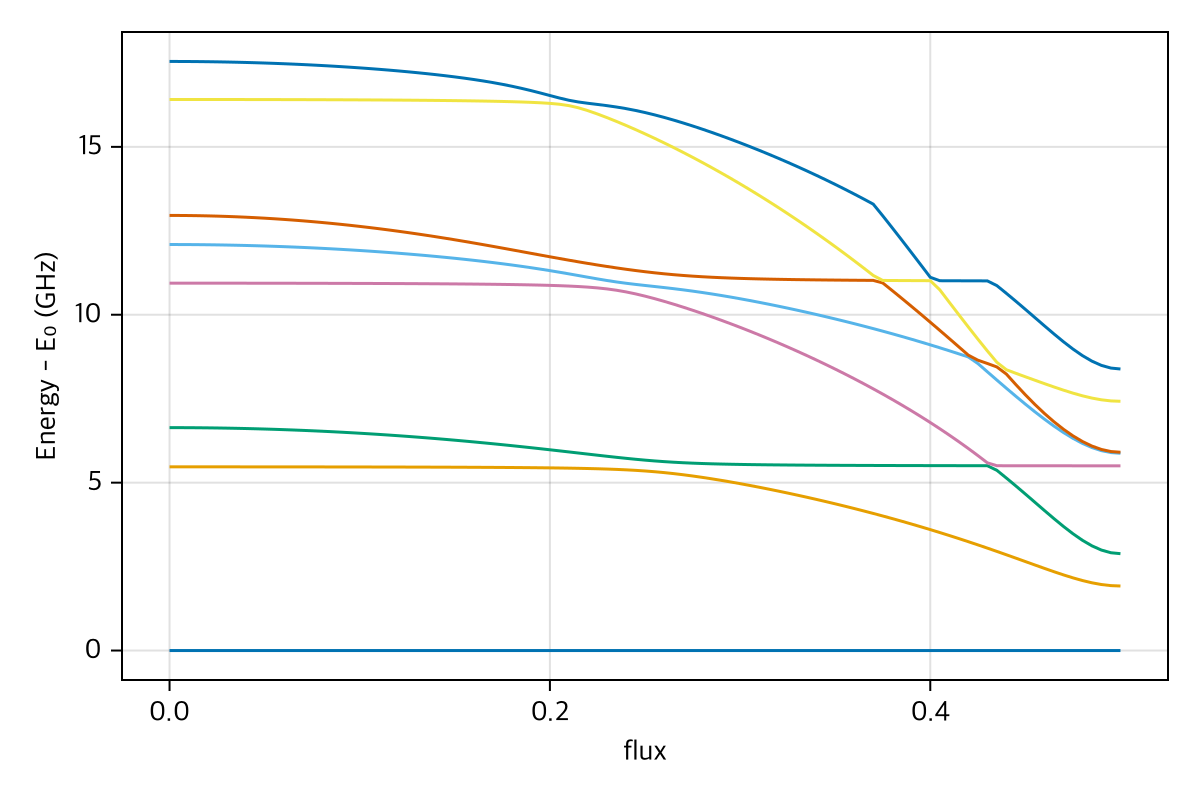

In [4]:
flux_vals = collect(range(0.0, 0.5, length=101))

sweep = ParameterSweep(hs,
    Dict(:flux => flux_vals),
    (hs, vals) -> begin
        hs.subsystems[1].flux = vals[:flux]
    end;
    evals_count=8
)

plot_evals_vs_paramvals(sweep; subtract_ground=true, evals_count=8)

## 4. Bare vs Dressed 전이 비교

Bare 큐비트의 전이 주파수와 dressed 전이 주파수를 비교하면 결합에 의한 에너지 이동(Lamb shift)을 확인할 수 있습니다.

In [5]:
# Bare vs Dressed 비교 (샘플 포인트)
sample_flux = range(0.0, 0.5, length=11)
println("  Φ/Φ₀    Bare ω₀₁    Res ω     Dressed ω₀₁   Lamb shift (MHz)")
println("  " * "-"^65)
for flux in sample_flux
    tmon.flux = flux
    bare_e = eigenvals(tmon; evals_count=2)
    bare_w01 = bare_e[2] - bare_e[1]

    # swept dressed 에너지에서 가장 가까운 인덱스 찾기
    idx = argmin(abs.(flux_vals .- flux))
    dressed_w01 = sweep.dressed_evals[idx, 2] - sweep.dressed_evals[idx, 1]
    lamb = (dressed_w01 - bare_w01) * 1000

    println("  $(round(flux, digits=2))      $(round(bare_w01, digits=4))    $(osc.E_osc)    $(round(dressed_w01, digits=4))       $(round(lamb, digits=2))")
end
tmon.flux = 0.0

  Φ/Φ₀    Bare ω₀₁    Res ω     Dressed ω₀₁   Lamb shift (MHz)
  -----------------------------------------------------------------
  0.0      6.6134    5.5    5.4702       -1143.2
  0.05      6.571    5.5    5.4694       -1101.59
  0.1      6.4431    5.5    5.4664       -976.68
  0.15      6.2282    5.5    5.4594       -768.84
  0.2      5.9232    5.5    5.4398       -483.34
  0.25      5.5224    5.5    5.3476       -174.81
  0.3      5.0166    5.5    4.97       -46.64
  0.35      4.3893    5.5    4.3692       -20.12
  0.4      3.6119    5.5    3.6013       -10.56
  0.45      2.6557    5.5    2.6499       -5.76
  0.5      1.9261    5.5    1.922       -4.05


0.0

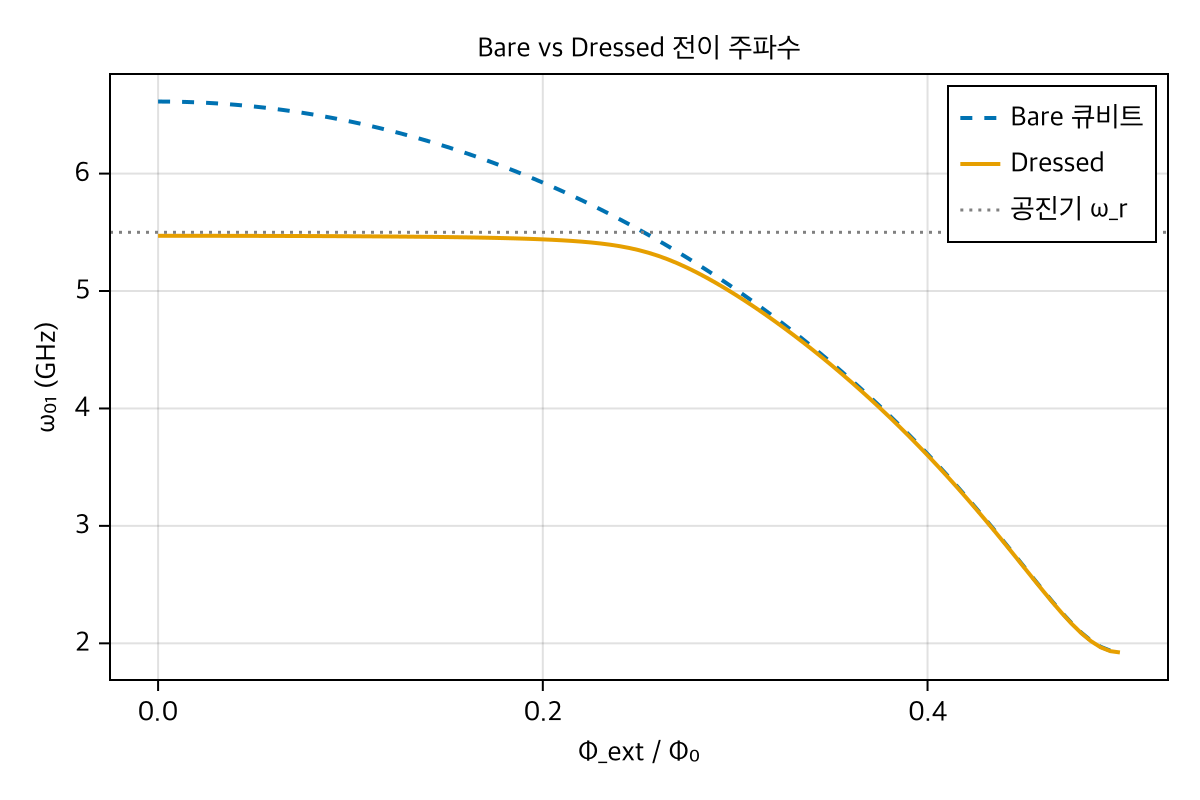

In [6]:
# Bare vs Dressed 오버레이 플롯
bare_w01_arr = Float64[]
for flux in flux_vals
    tmon.flux = flux
    e = eigenvals(tmon; evals_count=2)
    push!(bare_w01_arr, e[2] - e[1])
end
tmon.flux = 0.0

dressed_w01_arr = sweep.dressed_evals[:, 2] .- sweep.dressed_evals[:, 1]

fig = Figure(size=(600, 400))
ax = Axis(fig[1, 1],
    xlabel="Φ_ext / Φ₀",
    ylabel="ω₀₁ (GHz)",
    title="Bare vs Dressed 전이 주파수")
lines!(ax, flux_vals, bare_w01_arr, label="Bare 큐비트", linewidth=2, linestyle=:dash)
lines!(ax, flux_vals, dressed_w01_arr, label="Dressed", linewidth=2)
hlines!(ax, [osc.E_osc], color=:gray, linestyle=:dot, label="공진기 ω_r")
axislegend(ax)
fig

## 5. 상태 추적 (State Tracking)

`store_lookups=true` 옵션으로 스윕하면 각 파라미터 지점에서 bare/dressed 상태 매핑을 저장합니다. 이를 통해 스윕 과정에서 에너지 준위의 "정체"를 추적할 수 있습니다.

여기서 말하는 "정체"는 exact adiabatic branch identity라기보다 dominant bare-state character에 가깝습니다. 강한 hybridization 때문에 bare label이 빠지는 구간에서는 `ParameterSweep(...; store_lookups=true, ignore_low_overlap=true)`를 명시적으로 사용해 relaxed labeling을 켜야 합니다.



In [7]:
flux_fine = collect(range(0.0, 0.5, length=11))

sweep2 = ParameterSweep(hs,
    Dict(:flux => flux_fine),
    (hs, vals) -> begin
        hs.subsystems[1].flux = vals[:flux]
    end;
    evals_count=10,
    store_lookups=true,
    ignore_low_overlap=true
)

println("자속 스윕에 따른 상태 추적:")
for (i, flux) in enumerate(flux_fine)
    println("\n  Φ/Φ₀ = $(round(flux, digits=3)):")
    lk = sweep2.lookups[i]
    for di in 1:min(6, length(lk.dressed_evals))
        bi = get(lk.dressed_to_bare, di, nothing)
        e = lk.dressed_evals[di]
        if bi === nothing
            println("    dressed[$di] → unlabeled  E=$(round(e, digits=4)) GHz")
        else
            println("    dressed[$di] → |q=$(bi[1]-1), n=$(bi[2]-1)⟩  E=$(round(e, digits=4)) GHz")
        end
    end
end

자속 스윕에 따른 상태 추적:

  Φ/Φ₀ = 0.0:
    dressed[1] → |q=0, n=0⟩  E=-16.6152 GHz
    dressed[2] → |q=0, n=1⟩  E=-11.145 GHz
    dressed[3] → |q=1, n=0⟩  E=-9.977 GHz
    dressed[4] → |q=0, n=2⟩  E=-5.6749 GHz
    dressed[5] → |q=1, n=1⟩  E=-4.5241 GHz
    dressed[6] → |q=2, n=0⟩  E=-3.6579 GHz

  Φ/Φ₀ = 0.05:
    dressed[1] → |q=0, n=0⟩  E=-16.3926 GHz
    dressed[2] → |q=0, n=1⟩  E=-10.9232 GHz
    dressed[3] → |q=1, n=0⟩  E=-9.796 GHz
    dressed[4] → |q=0, n=2⟩  E=-5.454 GHz
    dressed[5] → |q=1, n=1⟩  E=-4.3455 GHz
    dressed[6] → |q=2, n=0⟩  E=-3.5173 GHz

  Φ/Φ₀ = 0.1:
    dressed[1] → |q=0, n=0⟩  E=-15.7313 GHz
    dressed[2] → |q=0, n=1⟩  E=-10.2649 GHz
    dressed[3] → |q=1, n=0⟩  E=-9.2596 GHz
    dressed[4] → |q=0, n=2⟩  E=-4.7987 GHz
    dressed[5] → |q=1, n=1⟩  E=-3.818 GHz
    dressed[6] → |q=2, n=0⟩  E=-3.1005 GHz

  Φ/Φ₀ = 0.15:
    dressed[1] → |q=0, n=0⟩  E=-14.6506 GHz
    dressed[2] → |q=0, n=1⟩  E=-9.1912 GHz
    dressed[3] → |q=1, n=0⟩  E=-8.3866 GHz
    dressed[4] →

## 6. Transition plots via preslicing

`ParameterSweep`는 이제 Julia-style preslicing view `SweepSlice`를 지원합니다. 1차원 스윕에서는 `sweep[:]`로 slice를 만든 뒤 `transitions(...)` 또는 `plot_transitions(...)`를 호출할 수 있습니다.

기본 `coloring="transition"`은 bare/dispersive labeling을 따라 강조선을 그리므로, avoided crossing 근처에서는 강조선이 끊기거나 branch를 바꾸어 탈 수 있습니다. 이것은 adiabatic lower/upper branch continuity를 보장하는 그림이 아닙니다. adiabatic branch 해석은 energy-sorted dressed spectrum처럼 별도의 관점으로 분리해서 봐야 합니다.



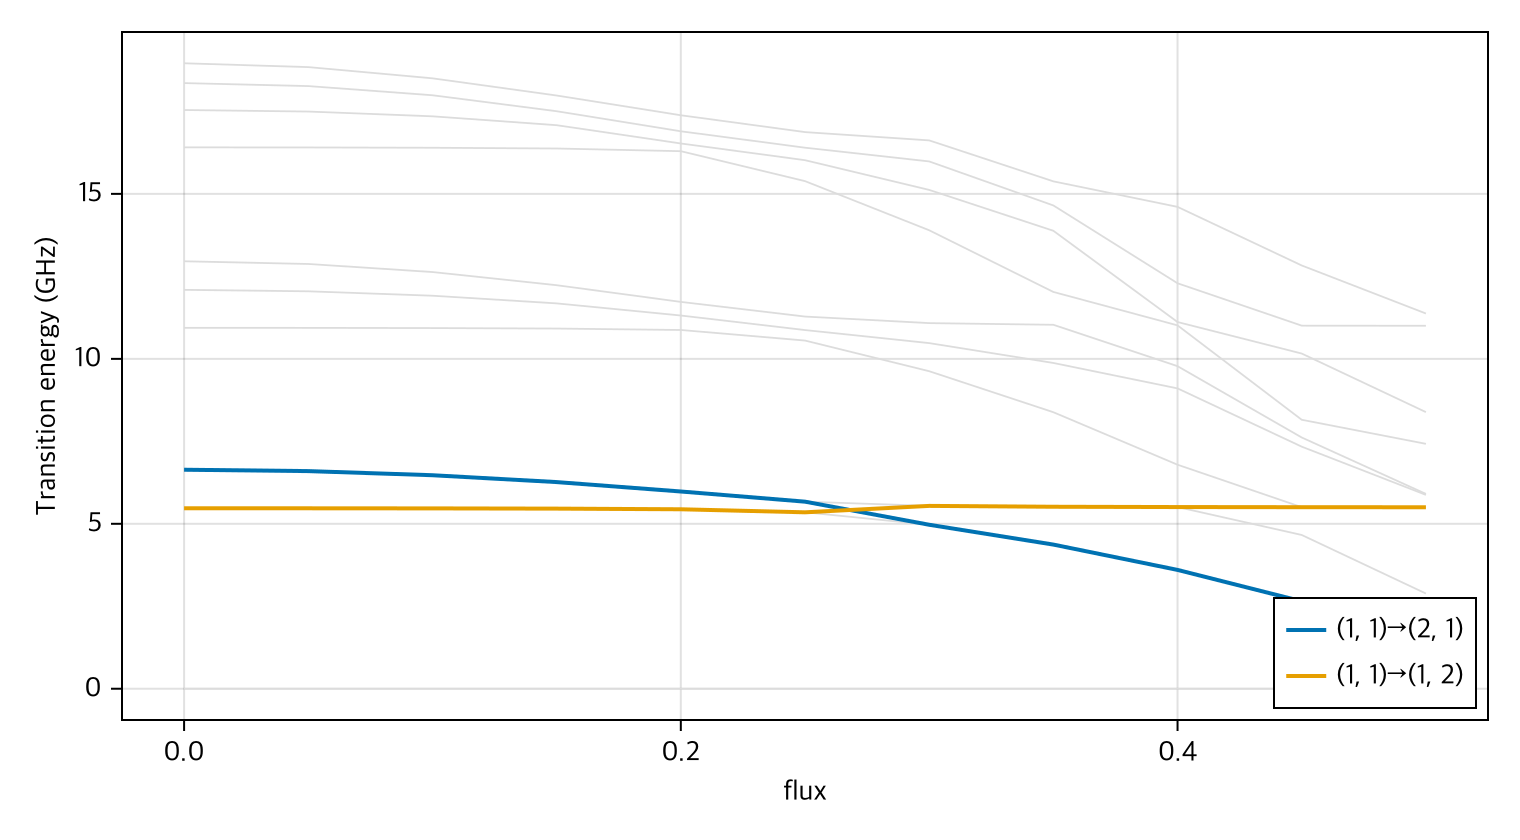

In [8]:
transition_slice = sweep2[:]
transition_labels, transition_energies = transitions(transition_slice; final=[(2, 1), (1, 2)])
transition_summary = collect(zip(transition_labels, [round.(energies; digits=6) for energies in transition_energies]))
plot_transitions(transition_slice; final=[(2, 1), (1, 2)])


## 7. Lookup ordering comparison: DE vs LX vs BE

The lookup machinery supports three public labeling schemes on the same dressed spectrum:

- `DE`: overlap-based dressed-energy labeling, which is the default choice
- `LX`: lexical branch analysis, which requires a complete dressed eigensystem
- `BE`: bare-energy branch analysis, which continues labels from the low bare-energy ordering

These are all **labeling schemes on the same Hamiltonian**, not different physical models. The comparison below keeps the avoided-crossing example fixed and only changes the lookup-ordering policy.



In [9]:
comparison_flux = flux_fine
comparison_evals_count = hilbertdim(hs)
comparison_BEs_count = 4
comparison_priority = [1, 2]
comparison_update = (hs, vals) -> begin
    hs.subsystems[1].flux = vals[:flux]
end

sweep_de = ParameterSweep(hs,
    Dict(:flux => comparison_flux),
    comparison_update;
    evals_count=comparison_evals_count,
    store_lookups=true,
    deepcopy=true)

sweep_lx = ParameterSweep(hs,
    Dict(:flux => comparison_flux),
    comparison_update;
    evals_count=comparison_evals_count,
    store_lookups=true,
    deepcopy=true,
    labeling_scheme=:LX,
    labeling_subsys_priority=comparison_priority)

sweep_be = ParameterSweep(hs,
    Dict(:flux => comparison_flux),
    comparison_update;
    evals_count=comparison_evals_count,
    store_lookups=true,
    deepcopy=true,
    labeling_scheme=:BE,
    labeling_subsys_priority=comparison_priority,
    labeling_BEs_count=comparison_BEs_count)

comparison_bare_w01 = Float64[]
for flux in comparison_flux
    tmon.flux = flux
    e = eigenvals(tmon; evals_count=2)
    push!(comparison_bare_w01, e[2] - e[1])
end
tmon.flux = 0.0

tracked_21_de = [energy_by_bare_index(sweep_de, 2, 1; param_indices=(i,), subtract_ground=true) for i in eachindex(comparison_flux)]
tracked_12_de = [energy_by_bare_index(sweep_de, 1, 2; param_indices=(i,), subtract_ground=true) for i in eachindex(comparison_flux)]
tracked_21_lx = [energy_by_bare_index(sweep_lx, 2, 1; param_indices=(i,), subtract_ground=true) for i in eachindex(comparison_flux)]
tracked_12_lx = [energy_by_bare_index(sweep_lx, 1, 2; param_indices=(i,), subtract_ground=true) for i in eachindex(comparison_flux)]
tracked_21_be = [energy_by_bare_index(sweep_be, 2, 1; param_indices=(i,), subtract_ground=true) for i in eachindex(comparison_flux)]
tracked_12_be = [energy_by_bare_index(sweep_be, 1, 2; param_indices=(i,), subtract_ground=true) for i in eachindex(comparison_flux)]

ordering_summary = (
    flux_points = length(comparison_flux),
    full_eval_count_for_LX = comparison_evals_count,
    BE_count = comparison_BEs_count,
    DE_assigned_labels_at_center = length(sweep_de.lookups[6].bare_to_dressed),
    LX_assigned_labels_at_center = length(sweep_lx.lookups[6].bare_to_dressed),
    BE_assigned_labels_at_center = length(sweep_be.lookups[6].bare_to_dressed),
)

ordering_summary



(flux_points = 11, full_eval_count_for_LX = 186, BE_count = 4, DE_assigned_labels_at_center = 162, LX_assigned_labels_at_center = 186, BE_assigned_labels_at_center = 4)

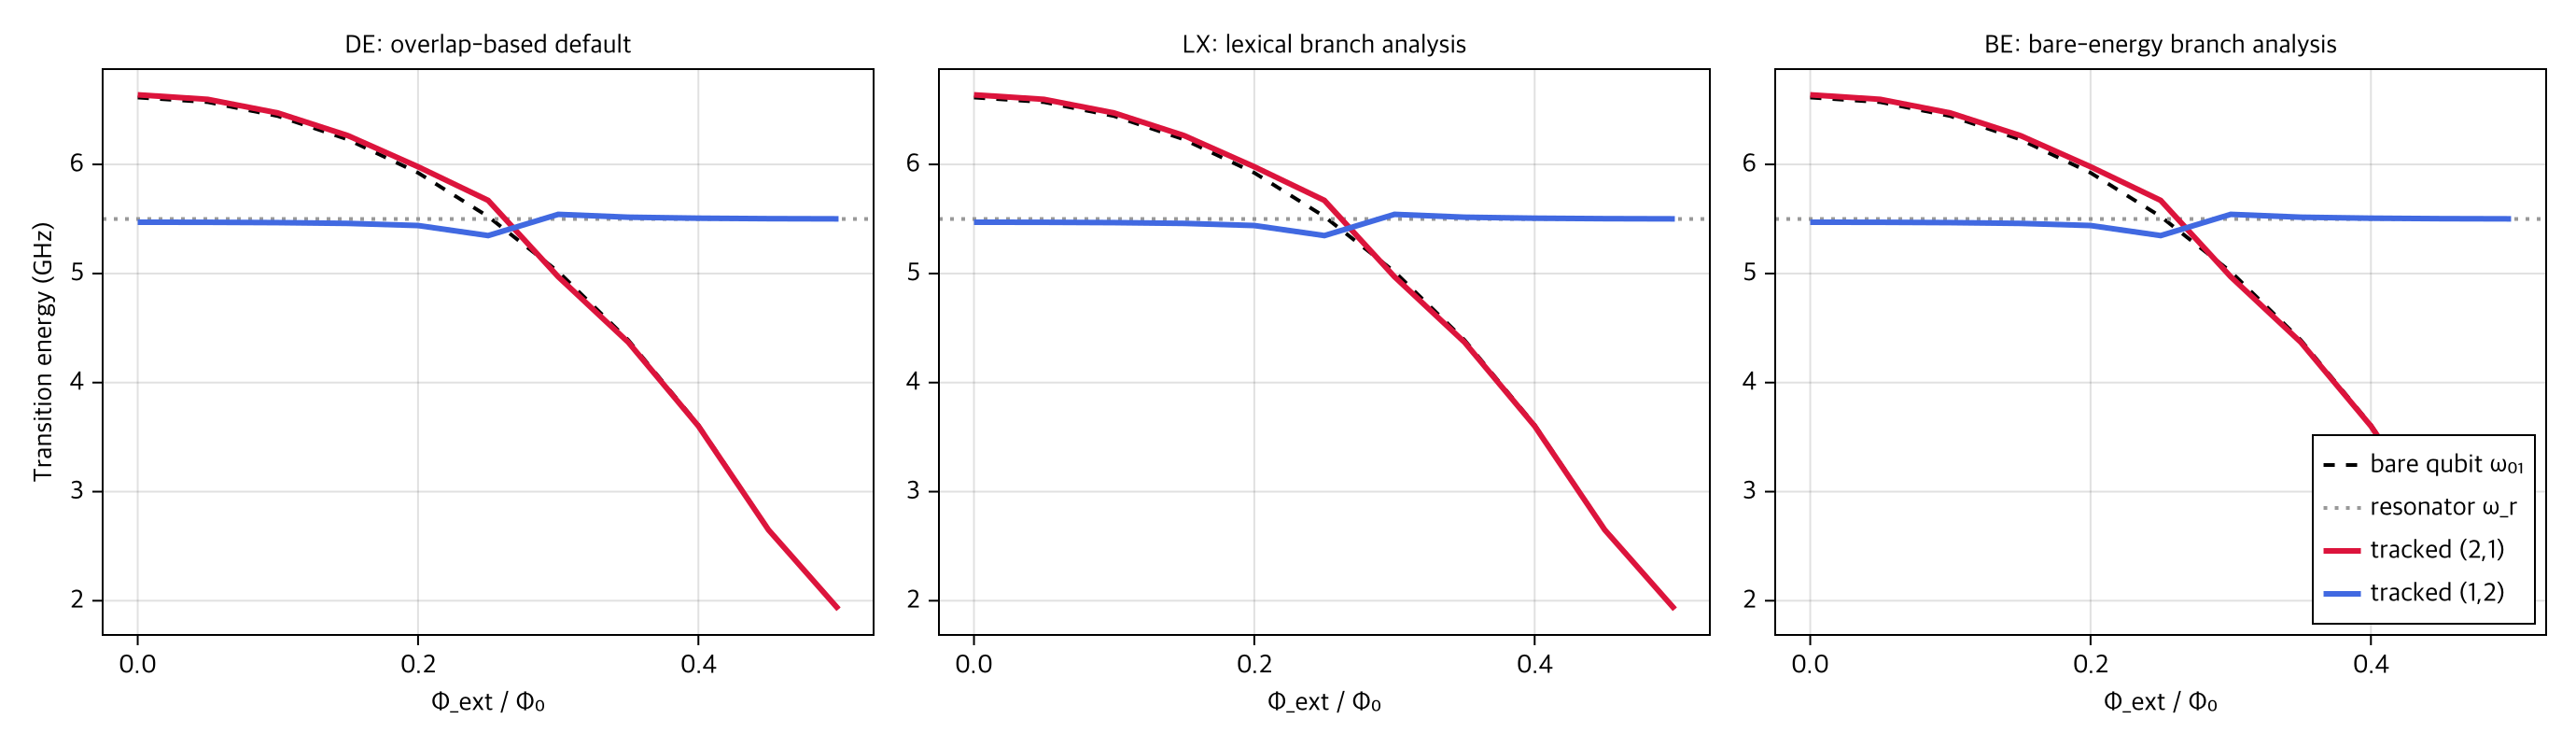

In [10]:
fig = Figure(size=(1380, 400))

panel_data = [
    ("DE: overlap-based default", tracked_21_de, tracked_12_de),
    ("LX: lexical branch analysis", tracked_21_lx, tracked_12_lx),
    ("BE: bare-energy branch analysis", tracked_21_be, tracked_12_be),
]

for (col, (title, tracked_21, tracked_12)) in enumerate(panel_data)
    subax = Axis(fig[1, col],
        xlabel="Φ_ext / Φ₀",
        ylabel=col == 1 ? "Transition energy (GHz)" : "",
        title=title)
    lines!(subax, comparison_flux, comparison_bare_w01; color=:black, linestyle=:dash, linewidth=2, label="bare qubit ω₀₁")
    hlines!(subax, [osc.E_osc]; color=:gray60, linestyle=:dot, linewidth=2, label="resonator ω_r")
    lines!(subax, comparison_flux, tracked_21; color=:crimson, linewidth=3, label="tracked (2,1)")
    lines!(subax, comparison_flux, tracked_12; color=:royalblue, linewidth=3, label="tracked (1,2)")
    col == 3 && axislegend(subax; position=:rb)
end

fig


What to notice in this avoided-crossing example:

- `DE` is the default, and it is the most conservative about refusing weak-overlap label assignments.
- `LX` and `BE` are alternative branch-labeling conventions that can keep labels available under stronger hybridization.
- None of these panels should be confused with adiabatic dressed-branch tracking; they are all bare-label tracking conventions applied to the same dressed spectrum.

Practical guidance: start with `DE`, and only reach for `LX` or `BE` when you intentionally want a different label-continuity convention.



## 8. 분산 시프트 $\chi$ vs 자속

분산 시프트는 큐비트 읽기(readout)의 핵심 파라미터입니다:

$$\chi_{ij} = E(1_i, 1_j) - E(1_i, 0_j) - E(0_i, 1_j) + E(0_i, 0_j)$$

자속에 따라 큐비트-공진기 디튜닝이 변하면서 $\chi$도 변합니다. 공진에 가까울수록 $\chi$가 커지지만, 동시에 dispersive 해석 자체는 약해지고 Purcell 감쇠도 증가합니다. 따라서 resonance 근처에서는 `\chi`를 exact dressed-spectrum에서 유도된 label-derived diagnostic으로 읽는 편이 더 정직합니다.


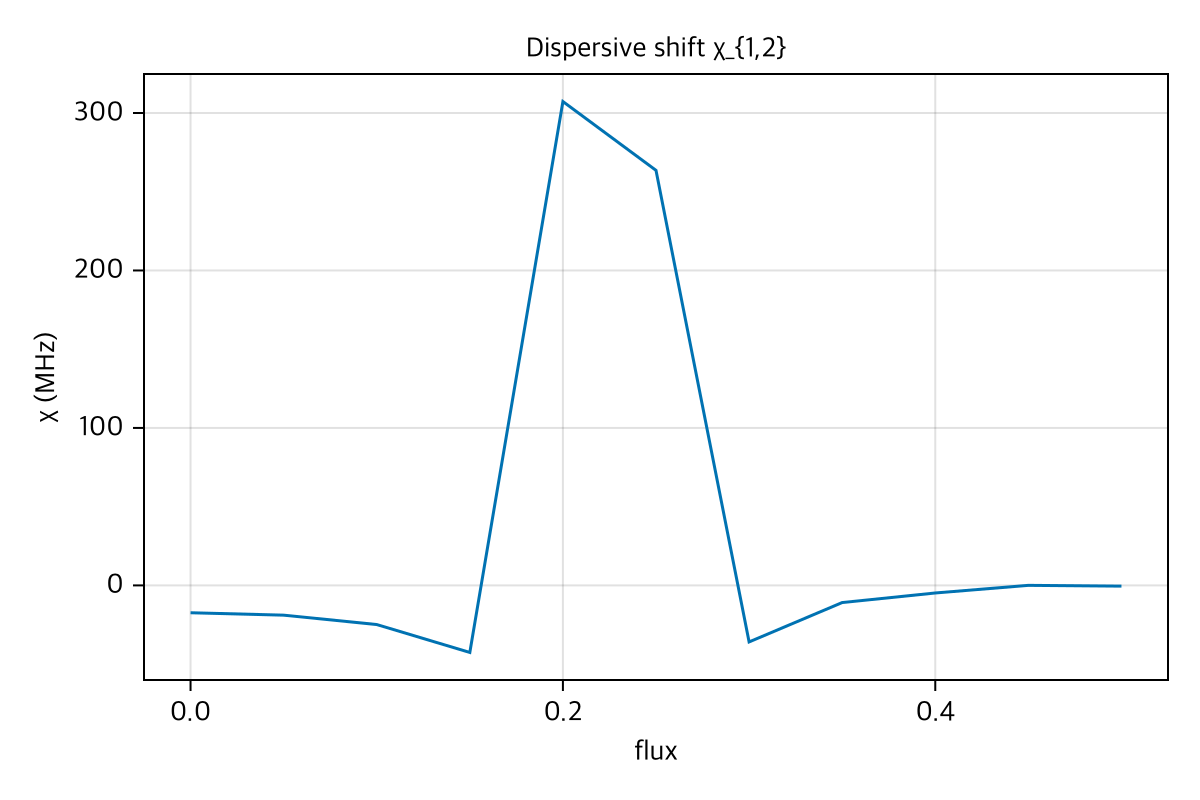

In [11]:
plot_chi_vs_paramvals(sweep2; subsys_pair=(1, 2))

In [12]:
# 수치 확인
println("분산 시프트 χ vs 자속:")
for (i, flux) in enumerate(flux_fine)
    lk = sweep2.lookups[i]
    try
        E00 = lk.dressed_evals[lk.bare_to_dressed[(1,1)]]
        E10 = lk.dressed_evals[lk.bare_to_dressed[(2,1)]]
        E01 = lk.dressed_evals[lk.bare_to_dressed[(1,2)]]
        E11 = lk.dressed_evals[lk.bare_to_dressed[(2,2)]]
        χ = (E11 - E10) - (E01 - E00)
        println("  Φ/Φ₀ = $(round(flux, digits=3)) → χ/2π = $(round(χ * 1000, digits=2)) MHz")
    catch ex
        println("  Φ/Φ₀ = $(round(flux, digits=3)) → 계산 불가")
    end
end

분산 시프트 χ vs 자속:
  Φ/Φ₀ = 0.0 → χ/2π = -17.36 MHz
  Φ/Φ₀ = 0.05 → χ/2π = -18.89 MHz
  Φ/Φ₀ = 0.1 → χ/2π = -24.85 MHz
  Φ/Φ₀ = 0.15 → χ/2π = -42.57 MHz
  Φ/Φ₀ = 0.2 → χ/2π = 307.27 MHz
  Φ/Φ₀ = 0.25 → χ/2π = 263.57 MHz
  Φ/Φ₀ = 0.3 → χ/2π = -35.88 MHz
  Φ/Φ₀ = 0.35 → χ/2π = -10.88 MHz
  Φ/Φ₀ = 0.4 → χ/2π = -4.8 MHz
  Φ/Φ₀ = 0.45 → χ/2π = 0.04 MHz
  Φ/Φ₀ = 0.5 → χ/2π = -0.46 MHz


## 9. 다중 큐비트 시스템

두 개의 TunableTransmon 큐비트를 공진기 버스(bus resonator)를 통해 결합하는 더 복잡한 시스템을 분석합니다.

$$H = H_{q1}(\Phi_1) + H_{q2} + H_{\text{bus}} + g_1 \hat{n}_1 (\hat{a} + \hat{a}^\dagger) + g_2 \hat{n}_2 (\hat{a} + \hat{a}^\dagger)$$


In [13]:
tmon1 = TunableTransmon(EJmax=25.0, EC=0.4, d=0.05, flux=0.0, ncut=10, truncated_dim=3)
tmon2 = TunableTransmon(EJmax=22.0, EC=0.35, d=0.08, flux=0.0, ncut=10, truncated_dim=3)
bus = Oscillator(E_osc=6.0, truncated_dim=4)

hs3 = HilbertSpace([tmon1, tmon2, bus])

g1, g2 = 0.12, 0.10
add_interaction!(hs3, g1, [tmon1, bus],
    [s -> n_operator(s),
     s -> annihilation_operator(s) + creation_operator(s)])
add_interaction!(hs3, g2, [tmon2, bus],
    [s -> n_operator(s),
     s -> annihilation_operator(s) + creation_operator(s)])

println("큐비트 1: EJmax=$(tmon1.EJmax), EC=$(tmon1.EC)")
println("큐비트 2: EJmax=$(tmon2.EJmax), EC=$(tmon2.EC)")
println("버스 공진기: ω=$(bus.E_osc) GHz")
println("전체 힐베르트 공간: $(hilbertdim(hs3))")

큐비트 1: EJmax=25.0, EC=0.4
큐비트 2: EJmax=22.0, EC=0.35
버스 공진기: ω=6.0 GHz
전체 힐베르트 공간: 1764


In [14]:
# 큐비트 1의 자속 스윕
sweep3 = ParameterSweep(hs3,
    Dict(:flux1 => collect(range(0.0, 0.4, length=5))),
    (hs, vals) -> begin
        hs.subsystems[1].flux = vals[:flux1]
    end;
    evals_count=8,
    store_lookups=true
)

println("Dressed 스펙트럼 vs 큐비트 1 자속:")
for (i, flux) in enumerate(sweep3.param_vals[:flux1])
    lk = sweep3.lookups[i]
    println("\n  Φ₁/Φ₀ = $(round(flux, digits=2)):")
    for di in 1:min(5, length(lk.dressed_evals))
        bi = get(lk.dressed_to_bare, di, nothing)
        e = lk.dressed_evals[di]
        if bi === nothing
            println("    dressed[$di] → unlabeled  E=$(round(e, digits=3)) GHz")
        else
            println("    dressed[$di] → |$(bi[1]-1),$(bi[2]-1),$(bi[3]-1)⟩  E=$(round(e, digits=3)) GHz")
        end
    end
end

Dressed 스펙트럼 vs 큐비트 1 자속:

  Φ₁/Φ₀ = 0.0:
    dressed[1] → |0,0,0⟩  E=-38.798 GHz
    dressed[2] → |0,0,1⟩  E=-32.817 GHz
    dressed[3] → |0,1,0⟩  E=-31.309 GHz
    dressed[4] → |1,0,0⟩  E=-30.268 GHz
    dressed[5] → |0,0,2⟩  E=-26.835 GHz

  Φ₁/Φ₀ = 0.1:
    dressed[1] → |0,0,0⟩  E=-37.688 GHz
    dressed[2] → |0,0,1⟩  E=-31.707 GHz
    dressed[3] → |0,1,0⟩  E=-30.199 GHz
    dressed[4] → |1,0,0⟩  E=-29.379 GHz
    dressed[5] → |0,0,2⟩  E=-25.727 GHz

  Φ₁/Φ₀ = 0.2:
    dressed[1] → |0,0,0⟩  E=-34.485 GHz
    dressed[2] → |0,0,1⟩  E=-28.507 GHz
    dressed[3] → |0,1,0⟩  E=-26.997 GHz
    dressed[4] → |1,0,0⟩  E=-26.851 GHz
    dressed[5] → |0,0,2⟩  E=-22.528 GHz

  Φ₁/Φ₀ = 0.3:
    dressed[1] → |0,0,0⟩  E=-29.567 GHz
    dressed[2] → |0,0,1⟩  E=-23.609 GHz
    dressed[3] → |1,0,0⟩  E=-23.101 GHz
    dressed[4] → |0,1,0⟩  E=-22.079 GHz
    dressed[5] → |0,0,2⟩  E=-17.653 GHz

  Φ₁/Φ₀ = 0.4:
    dressed[1] → |0,0,0⟩  E=-23.588 GHz
    dressed[2] → |1,0,0⟩  E=-19.032 GHz
    dressed[3]